## Exploratory Data Analysis (EDA)

Roles to Explore:

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x:
        ast.literal_eval(x)
        if pd.notna(x)
        else(x)
)

In [2]:
# Filter US Data Engineer Roles

df_de_us = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')]

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p..."
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}"


In [3]:
df_plot = df_de_us['job_location'].value_counts().head(10).to_frame()

df_plot

,count
job_location,
Anywhere,6285
"New York, NY",1212
United States,1111
"Dallas, TX",835
"Atlanta, GA",764
"Chicago, IL",714
"Austin, TX",619
"Washington, DC",611
"Charlotte, NC",599


Text(0, 0.5, '')

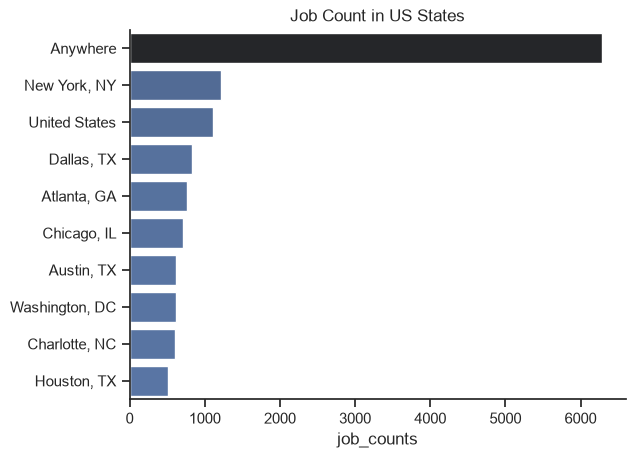

In [4]:
# plot for df_plot

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Job Count in US States')
plt.xlabel('job_counts')
plt.ylabel('')

In [5]:
df_de_us['job_no_degree_mention'].value_counts()

job_no_degree_mention
False    25422
True      9658
Name: count, dtype: int64

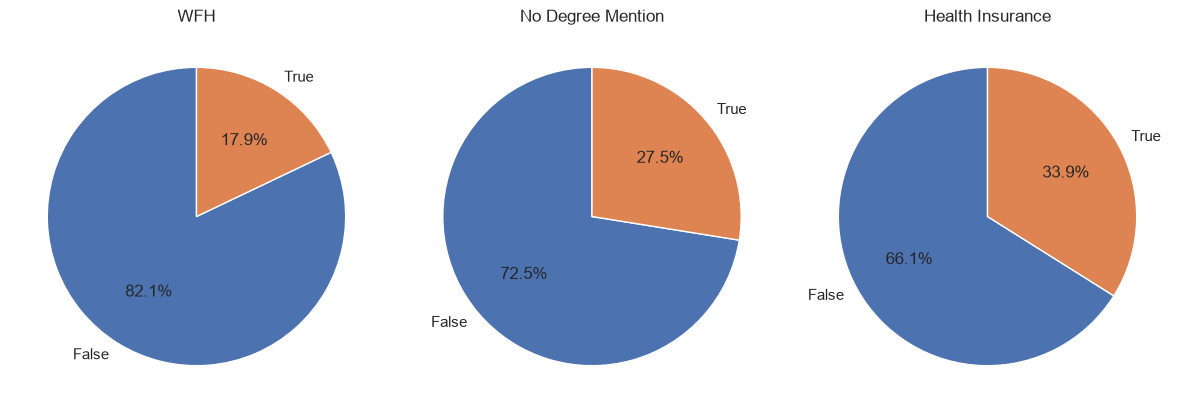

In [6]:
# pie plot for WFH, No Degree Mention, & Health Insurance

fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'WFH',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_de_us[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=(False, True))
    ax[i].set_title(title)

fig.set_size_inches(12,5)
fig.tight_layout()
plt.show()

In [7]:
df_plot_company = df_de_us['company_name'].value_counts().head(10).to_frame().copy()

df_plot_company

,count
company_name,
Dice,1036
Capital One,628
Booz Allen Hamilton,433
Insight Global,432
Upwork,335
Robert Half,281
Motion Recruitment,254
KPMG,246
KPMG US,239


Text(0, 0.5, '')

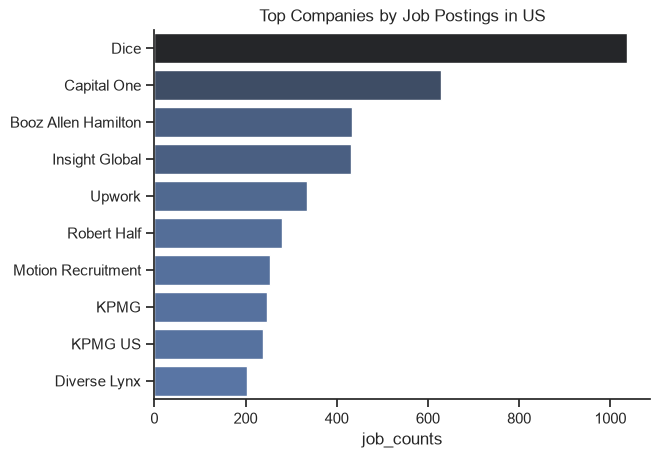

In [8]:
# company_name

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_company, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Top Companies by Job Postings in US')
plt.xlabel('job_counts')
plt.ylabel('')